In [1]:
import time
import faiss
import pandas as pd
from sentence_transformers import SentenceTransformer

d:\semantic-search-system\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = SentenceTransformer("all-MiniLM-L6-v2")

index = faiss.read_index("../models/faiss_index.bin")

df = pd.read_csv("../data/cleaned_newsgroups.csv")

documents = df["clean_text"].tolist()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5809.44it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
#measure search time
query = "space shuttle mission"
start=time.time()
query_embedding = model.encode([query])
D, I = index.search(query_embedding, k=5)
end = time.time()
print(f"Search time: {end-start:.4f} seconds")

Search time: 0.0620 seconds


In [5]:
test_queries = {
    "space shuttle launch": "sci.space",
    "hockey season playoffs": "rec.sport.hockey",
    "graphics rendering algorithm": "comp.graphics",
    "medical treatment infection": "sci.med"
}

correct = 0
total = 0

for query, expected_label in test_queries.items():

    query_embedding = model.encode([query])

    D, I = index.search(query_embedding, 5)

    results = df.iloc[I[0]]

    labels = results["label"].tolist()

    if expected_label in labels:
        correct += 1

    total += 1

precision = correct / total

print("Precision@5:", precision)

Precision@5: 1.0


In [6]:
#embedding time
import time

start = time.time()

model.encode(documents[:1000])

end = time.time()

print("Embedding time for 1000 docs:", end-start)

Embedding time for 1000 docs: 57.85160541534424


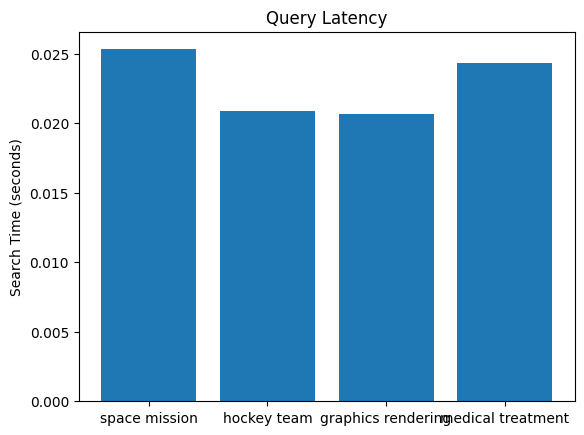

In [7]:
import matplotlib.pyplot as plt

queries = [
    "space mission",
    "hockey team",
    "graphics rendering",
    "medical treatment"
]

times = []

for q in queries:

    start = time.time()

    query_embedding = model.encode([q])

    index.search(query_embedding, 5)

    times.append(time.time() - start)

plt.bar(queries, times)
plt.ylabel("Search Time (seconds)")
plt.title("Query Latency")
plt.show()